# Imports & Loading the data

In [1]:
#1 — Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [2]:
#2 — Load files (safe row-group read)
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [3]:
#3 — Build PD label

# Maps “Checked/Unchecked” → 1/0.
pheno['parkinsons_label'] = pheno['parkinsons'].map({'Checked':1, 'Unchecked':0})
labels = pheno[['participant_id','parkinsons_label']].dropna()
labels['parkinsons_label'] = labels['parkinsons_label'].astype(int)
labels['parkinsons_label'].value_counts()


parkinsons_label
0    381
1     61
Name: count, dtype: int64

In [4]:
#4 — Merge

# Joins spectrograms with labels by participant_id.
data = spec.merge(labels, on='participant_id', how='inner')
print("merged:", data.shape)
data[['participant_id','session_id','task_name','parkinsons_label']].head(3)


merged: (16738, 5)


,participant_id,session_id,task_name,parkinsons_label
0,004d42e9,07031CC3,Animal-fluency,0
1,004d42e9,07031CC3,Cinderella-Story,0
2,004d42e9,07031CC3,Diadochokinesis-KA,0


# EDA

In [7]:
#5 — Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


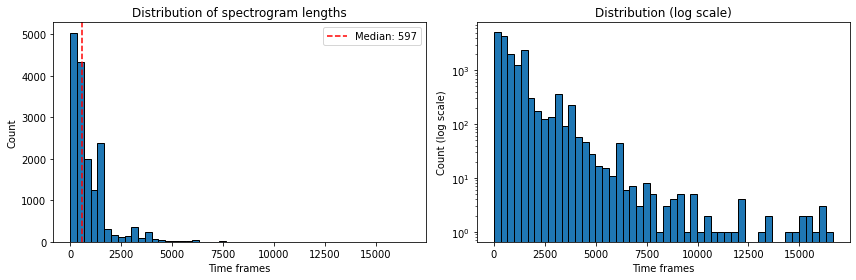


Total samples: 16738


In [8]:
#6 — Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [9]:
#7 — Investigate short recordings and length vs label relationship
import numpy as np

# Add time dimension to dataframe for analysis
data['time_frames'] = data['spectrogram'].apply(lambda x: len(x[0]))

# Check very short recordings
short_threshold = 100
short_recordings = data[data['time_frames'] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print(f"Their task distribution:\n{short_recordings['task_name'].value_counts()}")
print(f"Their PD label distribution:\n{short_recordings['parkinsons_label'].value_counts()}")

# Check if length correlates with PD status (potential bias)
print("\n--- Time frames by PD status ---")
for label in [0, 1]:
    subset = data[data['parkinsons_label'] == label]['time_frames']
    print(f"PD={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

# Check task distribution overall
print("\n--- Task distribution ---")
print(data['task_name'].value_counts())

# Check task distribution by PD status
print("\n--- Tasks by PD status ---")
print(pd.crosstab(data['task_name'], data['parkinsons_label']))

Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

Short recordings (<100 frames): Mostly respiration/breath tasks, these are intentionally short (breaths, coughs). Not data quality issues, just naturally short tasks.
Length by PD status: Slight difference (PD=1 has mean 1062 vs PD=0 has 904), but medians are similar (607 vs 592). Not a major concern for bias.

Critical finding, Task imbalance by PD status:

Some tasks have almost NO PD patients: Cape-V-sentences (218 vs 1), Caterpillar-Passage (218 vs 1), Free-Speech (167 vs 0)
Some tasks have MORE PD than non-PD: Cinderella-Story (66 vs 85), Word-color-Stroop (67 vs 84)
Balanced tasks: Diadochokinesis-*, Rainbow-Passage, Prolonged-vowel, etc. (~395 vs ~86)


This is important: If we train on all tasks together, the model might learn task-specific patterns rather than PD-specific voice biomarkers. The imbalanced task distribution could confound results.

# Select HIGH PD-ratio tasks + process raw spectrograms + split + Visualization

In [10]:
#8 — Select HIGH PD-ratio tasks + process raw spectrograms + split
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print("="*75)
print("STRATEGY: Train ONLY on high PD-ratio tasks (56% PD)")
print("="*75)

# STEP 1: Select ONLY high PD-ratio tasks

high_pd_only_tasks = [
    'Cinderella-Story',           
    'Productive-Vocabulary-1',
    'Productive-Vocabulary-2',
    'Productive-Vocabulary-3',
    'Productive-Vocabulary-4',
    'Productive-Vocabulary-5',
    'Productive-Vocabulary-6',
    'Word-color-Stroop',          
    'Random-Item-Generation',
]

min_time_frames = 100
data_high_pd = data[
    (data['task_name'].isin(high_pd_only_tasks)) & 
    (data['time_frames'] >= min_time_frames)
].copy()

print(f"\n### High PD-ratio tasks only ###")
print(f"Total samples: {len(data_high_pd)}")
print(f"PD samples: {data_high_pd['parkinsons_label'].sum()}")
print(f"Non-PD samples: {(data_high_pd['parkinsons_label'] == 0).sum()}")
print(f"PD ratio: {data_high_pd['parkinsons_label'].mean():.2%}")

print(f"\nParticipants:")
print(f"  Total: {data_high_pd['participant_id'].nunique()}")
print(f"  PD: {data_high_pd[data_high_pd['parkinsons_label']==1]['participant_id'].nunique()}")
print(f"  Non-PD: {data_high_pd[data_high_pd['parkinsons_label']==0]['participant_id'].nunique()}")

print(f"\nSamples per task:")
print(data_high_pd['task_name'].value_counts())

# STEP 2: Process RAW spectrograms

print(f"\n### Processing RAW spectrograms ###")

TARGET_SEQ_LEN = 1024  # Longer sequence for these tasks

def process_spectrogram_raw(spec_raw, target_len=1024):
    """Process raw spectrogram with reflect padding."""
    spec = np.stack(spec_raw).astype(np.float32)
    n_mels, time_len = spec.shape
    
    if time_len < target_len:
        # Reflect padding (better than zero padding for spectrograms)
        pad_width = target_len - time_len
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='reflect')
    elif time_len > target_len:
        # Center crop
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]
    
    return spec

X_list = []
for idx, row in tqdm(data_high_pd.iterrows(), total=len(data_high_pd), desc="Processing"):
    processed = process_spectrogram_raw(row['spectrogram'], TARGET_SEQ_LEN)
    X_list.append(processed)

X_raw = np.stack(X_list)
y_raw = data_high_pd['parkinsons_label'].values
participants_raw = data_high_pd['participant_id'].values

print(f"\nProcessed shape: {X_raw.shape}")
print(f"Value range: [{X_raw.min():.2f}, {X_raw.max():.2f}]")

# STEP 3: Participant-level train/test split

unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

print(f"\n### Participant Statistics ###")
print(f"Unique participants: {len(unique_parts)}")
print(f"PD participants: {part_labels.sum()}")
print(f"Non-PD participants: {(part_labels == 0).sum()}")

# Stratified split by participant
train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=42
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print(f"\n### Train/Test Split ###")
print(f"Train: {len(X_train)} samples from {len(train_parts)} participants")
print(f"  PD: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test: {len(X_test)} samples from {len(test_parts)} participants")
print(f"  PD: {y_test.sum()} ({y_test.mean():.1%})")

# Verify no participant overlap
assert len(set(train_parts) & set(test_parts)) == 0, "Data leakage detected!"
print(f"\n✓ No participant overlap between train and test sets")


STRATEGY: Train ONLY on high PD-ratio tasks (56% PD)

### High PD-ratio tasks only ###
Total samples: 1349
PD samples: 757
Non-PD samples: 592
PD ratio: 56.12%

Participants:
  Total: 112
  PD: 59
  Non-PD: 53

Samples per task:
task_name
Productive-Vocabulary-4    151
Word-color-Stroop          151
Productive-Vocabulary-3    151
Productive-Vocabulary-5    151
Productive-Vocabulary-1    150
Productive-Vocabulary-6    150
Productive-Vocabulary-2    150
Random-Item-Generation     150
Cinderella-Story           145
Name: count, dtype: int64

### Processing RAW spectrograms ###


Processing: 100%|██████████| 1349/1349 [00:01<00:00, 1237.30it/s]



Processed shape: (1349, 201, 1024)
Value range: [-100.00, 46.02]

### Participant Statistics ###
Unique participants: 112
PD participants: 59
Non-PD participants: 53

### Train/Test Split ###
Train: 1133 samples from 89 participants
  PD: 640 (56.5%)
Test: 216 samples from 23 participants
  PD: 117 (54.2%)

✓ No participant overlap between train and test sets


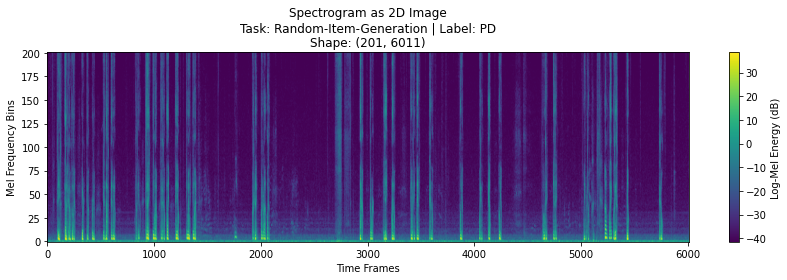

X-axis (horizontal): Time progression →
Y-axis (vertical): Frequency (low to high) ↑
Color intensity: Energy/loudness at that time-frequency point

AST treats this 2D image like a photo, splitting into 16×16 patches.


In [35]:
# Visualize spectrogram as 2D image representation
import matplotlib.pyplot as plt
import numpy as np

# Get one sample
sample_idx = 52
spec_sample = np.stack(data_high_pd.iloc[sample_idx]['spectrogram'])
task_name = data_high_pd.iloc[sample_idx]['task_name']
label = data_high_pd.iloc[sample_idx]['parkinsons_label']

fig, ax = plt.subplots(figsize=(12, 4))

img = ax.imshow(spec_sample, aspect='auto', origin='lower', cmap='viridis')
ax.set_xlabel('Time Frames')
ax.set_ylabel('Mel Frequency Bins')
ax.set_title(f'Spectrogram as 2D Image\nTask: {task_name} | Label: {"PD" if label==1 else "Non-PD"}\nShape: {spec_sample.shape}')
plt.colorbar(img, ax=ax, label='Log-Mel Energy (dB)')

plt.tight_layout()
plt.savefig('spectrogram_visualization.png', dpi=150)
plt.show()

print("X-axis (horizontal): Time progression →")
print("Y-axis (vertical): Frequency (low to high) ↑")
print("Color intensity: Energy/loudness at that time-frequency point")
print("\nAST treats this 2D image like a photo, splitting into 16×16 patches.")

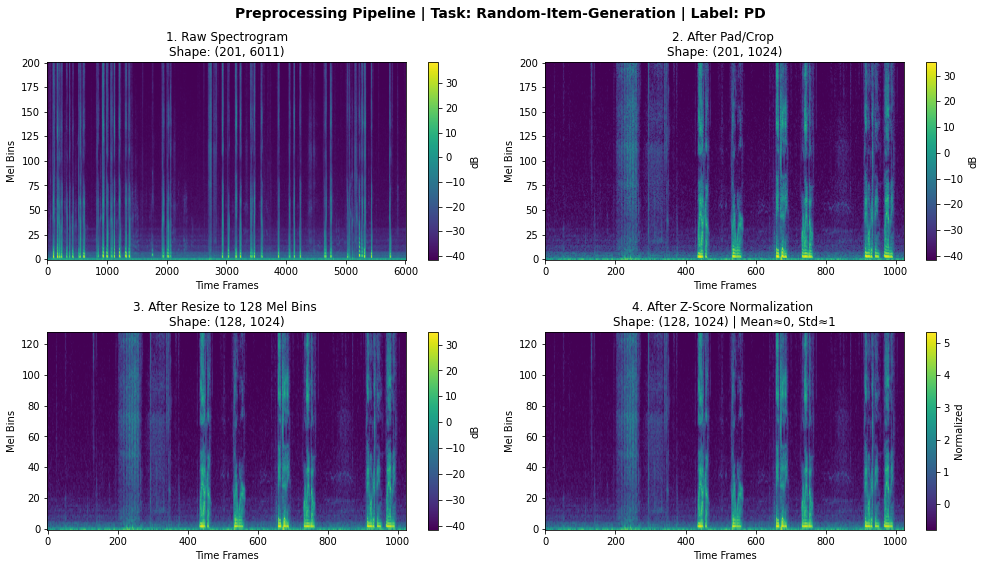

Preprocessing Summary:
  Raw:        (201, 6011) → Variable time length
  Pad/Crop:   (201, 1024) → Fixed 1024 time frames
  Resize:     (128, 1024) → 128 mel bins for AST
  Normalize:  (128, 1024) → Mean=0, Std=1


In [37]:
# Visualize spectrogram before and after preprocessing
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom

# Get one sample
sample_idx = 52
raw_spec = np.stack(data_high_pd.iloc[sample_idx]['spectrogram'])
task_name = data_high_pd.iloc[sample_idx]['task_name']
label = "PD" if data_high_pd.iloc[sample_idx]['parkinsons_label'] == 1 else "Non-PD"

# Step 1: Pad/Crop to 1024 (Cell #8 preprocessing)
def preprocess_step1(spec, target_len=1024):
    n_mels, time_len = spec.shape
    if time_len < target_len:
        spec = np.pad(spec, ((0, 0), (0, target_len - time_len)), mode='reflect')
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]
    return spec

# Step 2: Resize to 128 mel bins (Cell #9 preprocessing)
def preprocess_step2(spec, target_mel=128, target_time=1024):
    mel_ratio = target_mel / spec.shape[0]
    time_ratio = target_time / spec.shape[1]
    return zoom(spec, (mel_ratio, time_ratio), order=1)

# Step 3: Normalize (Cell #9 preprocessing)
def preprocess_step3(spec, mean, std):
    return (spec - mean) / (std + 1e-8)

# Apply preprocessing steps
step1_spec = preprocess_step1(raw_spec.copy())
step2_spec = preprocess_step2(step1_spec.copy())
step3_spec = preprocess_step3(step2_spec.copy(), step2_spec.mean(), step2_spec.std())

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Raw spectrogram
ax1 = axes[0, 0]
im1 = ax1.imshow(raw_spec, aspect='auto', origin='lower', cmap='viridis')
ax1.set_title(f'1. Raw Spectrogram\nShape: {raw_spec.shape}')
ax1.set_xlabel('Time Frames')
ax1.set_ylabel('Mel Bins')
plt.colorbar(im1, ax=ax1, label='dB')

# After pad/crop
ax2 = axes[0, 1]
im2 = ax2.imshow(step1_spec, aspect='auto', origin='lower', cmap='viridis')
ax2.set_title(f'2. After Pad/Crop \nShape: {step1_spec.shape}')
ax2.set_xlabel('Time Frames')
ax2.set_ylabel('Mel Bins')
plt.colorbar(im2, ax=ax2, label='dB')

# After resize
ax3 = axes[1, 0]
im3 = ax3.imshow(step2_spec, aspect='auto', origin='lower', cmap='viridis')
ax3.set_title(f'3. After Resize to 128 Mel Bins \nShape: {step2_spec.shape}')
ax3.set_xlabel('Time Frames')
ax3.set_ylabel('Mel Bins')
plt.colorbar(im3, ax=ax3, label='dB')

# After normalization
ax4 = axes[1, 1]
im4 = ax4.imshow(step3_spec, aspect='auto', origin='lower', cmap='viridis')
ax4.set_title(f'4. After Z-Score Normalization \nShape: {step3_spec.shape} | Mean≈0, Std≈1')
ax4.set_xlabel('Time Frames')
ax4.set_ylabel('Mel Bins')
plt.colorbar(im4, ax=ax4, label='Normalized')

plt.suptitle(f'Preprocessing Pipeline | Task: {task_name} | Label: {label}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150)
plt.show()

print("Preprocessing Summary:")
print(f"  Raw:        {raw_spec.shape} → Variable time length")
print(f"  Pad/Crop:   {step1_spec.shape} → Fixed 1024 time frames")
print(f"  Resize:     {step2_spec.shape} → 128 mel bins for AST")
print(f"  Normalize:  {step3_spec.shape} → Mean=0, Std=1")

In [38]:
# List of your selected high-PD-prevalence tasks
selected_tasks = [
    "Cinderella-Story",
    "Productive-Vocabulary-1",
    "Productive-Vocabulary-2",
    "Productive-Vocabulary-3",
    "Productive-Vocabulary-4",
    "Productive-Vocabulary-5",
    "Productive-Vocabulary-6",
    "Random-Item-Generation",
    "Animal-fluency"
]

# Filter data to selected tasks
subset = data[data["task_name"].isin(selected_tasks)]

# Count unique participants by label
subset_counts = subset.groupby("parkinsons_label")["participant_id"].nunique()
print(subset_counts)

# Optional: print numbers clearly
print(f"Non PD participants: {subset_counts.get(0, 0)}")
print(f"PD participants: {subset_counts.get(1, 0)}")


parkinsons_label
0    112
1     59
Name: participant_id, dtype: int64
Non PD participants: 112
PD participants: 59


# Modelling

In [10]:
#9 — Audio Spectrogram Transformer (AST) with pre-trained weights
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import ASTModel, ASTConfig
from tqdm import tqdm
from scipy.ndimage import zoom

print("="*75)
print("AUDIO SPECTROGRAM TRANSFORMER (AST) WITH PRETRAINED WEIGHTS")
print("="*75)

# STEP 1: Resize spectrograms for AST format

# AST expects 128 mel bins, we have 201 mel bins
def resize_spectrogram(spec, target_mel=128, target_time=1024):
    """Resize spectrogram to AST expected dimensions."""
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

print("Resizing spectrograms for AST (128 mel bins, 1024 time frames)...")

X_train_ast = []
for i in tqdm(range(len(X_train)), desc="Train"):
    resized = resize_spectrogram(X_train[i], target_mel=128, target_time=1024)
    X_train_ast.append(resized)
X_train_ast = np.stack(X_train_ast)

X_test_ast = []
for i in tqdm(range(len(X_test)), desc="Test"):
    resized = resize_spectrogram(X_test[i], target_mel=128, target_time=1024)
    X_test_ast.append(resized)
X_test_ast = np.stack(X_test_ast)

print(f"\nResized shapes:")
print(f"  Train: {X_train_ast.shape}")
print(f"  Test: {X_test_ast.shape}")

# Normalize
ast_mean = X_train_ast.mean()
ast_std = X_train_ast.std()
X_train_ast_norm = (X_train_ast - ast_mean) / (ast_std + 1e-8)
X_test_ast_norm = (X_test_ast - ast_mean) / (ast_std + 1e-8)

print(f"Normalized - Train: mean={X_train_ast_norm.mean():.4f}, std={X_train_ast_norm.std():.4f}")

# STEP 2: AST Classifier model

class ASTClassifier(nn.Module):
    """AST-based classifier using pre-trained weights."""
    def __init__(self, num_classes=2, pretrained=True, freeze_base=False):
        super().__init__()
        
        if pretrained:
            print("Loading pre-trained AST model...")
            self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
            hidden_size = self.ast.config.hidden_size  # 768
        else:
            config = ASTConfig(
                hidden_size=768,
                num_hidden_layers=12,
                num_attention_heads=12,
                intermediate_size=3072,
                max_length=1024,
                num_mel_bins=128,
            )
            self.ast = ASTModel(config)
            hidden_size = 768
        
        if freeze_base:
            for param in self.ast.parameters():
                param.requires_grad = False
        
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Linear(hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, 128, 1024) -> transpose to (batch, 1024, 128)
        x = x.transpose(1, 2)
        outputs = self.ast(input_values=x)
        pooled = outputs.pooler_output
        logits = self.classifier(pooled)
        return logits

# STEP 3: Dataset and DataLoaders

class ASTDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        
        if self.augment:
            # Time mask
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            # Frequency mask
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        
        return {
            'inputs': x,
            'labels': self.y[idx],
            'participant': self.participants[idx]
        }

train_ds_ast = ASTDataset(X_train_ast_norm, y_train, parts_train, augment=True)
test_ds_ast = ASTDataset(X_test_ast_norm, y_test, parts_test, augment=False)

# Balanced sampler
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

BATCH_SIZE = 8

train_loader_ast = torch.utils.data.DataLoader(
    train_ds_ast, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True
)
test_loader_ast = torch.utils.data.DataLoader(
    test_ds_ast, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

print(f"\nDataLoaders: Train={len(train_loader_ast)} batches, Test={len(test_loader_ast)} batches")

# STEP 4: Initialize model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_ast = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)

total_params = sum(p.numel() for p in model_ast.parameters())
trainable_params = sum(p.numel() for p in model_ast.parameters() if p.requires_grad)
print(f"\nAST Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Test forward pass
with torch.no_grad():
    test_batch = next(iter(train_loader_ast))
    test_input = test_batch['inputs'].to(device)
    test_output = model_ast(test_input)
    print(f"  Forward pass: {test_input.shape} -> {test_output.shape}")

print("\n✓ AST model ready!")

AUDIO SPECTROGRAM TRANSFORMER (AST) WITH PRETRAINED WEIGHTS
Resizing spectrograms for AST (128 mel bins, 1024 time frames)...


Test: 100%|██████████| 216/216 [00:00<00:00, 458.04it/s]



Resized shapes:
  Train: (1133, 128, 1024)
  Test: (216, 128, 1024)
Normalized - Train: mean=-0.0000, std=1.0000

DataLoaders: Train=142 batches, Test=27 batches
Device: cuda
Loading pre-trained AST model...

AST Model:
  Total parameters: 86,386,178
  Trainable parameters: 86,386,178
  Forward pass: torch.Size([8, 128, 1024]) -> torch.Size([8, 2])

✓ AST model ready!


In [11]:
#10 — Train pre-trained AST with careful fine-tuning
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import copy
import time

# Training setup for fine-tuning pre-trained model

def get_optimizer_groups(model, lr_backbone=1e-5, lr_head=1e-4, weight_decay=0.01):
    """Separate learning rates for backbone and head."""
    backbone_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if 'classifier' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    
    return [
        {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': weight_decay},
        {'params': head_params, 'lr': lr_head, 'weight_decay': weight_decay}
    ]

optimizer = torch.optim.AdamW(
    get_optimizer_groups(model_ast, lr_backbone=5e-6, lr_head=5e-4),
    betas=(0.9, 0.999)
)

NUM_EPOCHS = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

# Focal loss for imbalanced data
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

class_weights = torch.tensor([0.56, 0.44], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

# Evaluation function

def evaluate_ast(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    
    with torch.no_grad():
        for batch in loader:
            inputs = batch['inputs'].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_parts.extend(batch['participant'])
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)
    
    # Participant-level aggregation
    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        mask = all_parts == p
        part_probs.append(all_probs[mask].mean())
        part_labels.append(all_labels[mask][0])
    
    part_probs = np.array(part_probs)
    part_labels = np.array(part_labels)
    
    # Metrics
    if len(np.unique(part_labels)) > 1:
        part_auc = roc_auc_score(part_labels, part_probs)
        fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_thresh = thresholds[optimal_idx]
    else:
        part_auc = 0.5
        optimal_thresh = 0.5
    
    part_preds = (part_probs >= 0.5).astype(int)
    part_preds_opt = (part_probs >= optimal_thresh).astype(int)
    
    return {
        'part_auc': part_auc,
        'part_f1': f1_score(part_labels, part_preds, zero_division=0),
        'part_f1_opt': f1_score(part_labels, part_preds_opt, zero_division=0),
        'part_recall_opt': recall_score(part_labels, part_preds_opt, zero_division=0),
        'part_prec_opt': precision_score(part_labels, part_preds_opt, zero_division=0),
        'optimal_thresh': optimal_thresh,
        'part_probs': part_probs,
        'part_labels': part_labels
    }

# Training loop

best_f1 = 0.0
best_auc = 0.0
best_model_state = None
best_epoch = 0
best_metrics = None
patience = 15
patience_counter = 0

print("="*75)
print("FINE-TUNING PRE-TRAINED AST")
print("="*75)
print(f"Epochs: {NUM_EPOCHS}, Patience: {patience}")
print(f"Train: {len(train_ds_ast)} samples ({y_train.mean():.1%} PD)")
print(f"Test: {len(test_ds_ast)} samples ({y_test.mean():.1%} PD)")
print(f"Backbone LR: 5e-6, Head LR: 5e-4")
print("="*75 + "\n")

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_ast.train()
    total_loss = 0
    
    pbar = tqdm(train_loader_ast, desc=f'Epoch {epoch+1:02d}', leave=False)
    for batch in pbar:
        inputs = batch['inputs'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = model_ast(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ast.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    scheduler.step()
    avg_loss = total_loss / len(train_loader_ast)
    
    # Evaluate
    metrics = evaluate_ast(model_ast, test_loader_ast, device)
    
    # Track best by combined score
    score = 0.4 * metrics['part_auc'] + 0.6 * metrics['part_f1_opt']
    best_combined = 0.4 * best_auc + 0.6 * best_f1
    
    if score > best_combined + 0.01:
        best_f1 = metrics['part_f1_opt']
        best_auc = metrics['part_auc']
        best_model_state = copy.deepcopy(model_ast.state_dict())
        best_epoch = epoch + 1
        best_metrics = metrics.copy()
        patience_counter = 0
        marker = "★ BEST"
    else:
        patience_counter += 1
        marker = ""
    
    lr_backbone = optimizer.param_groups[0]['lr']
    lr_head = optimizer.param_groups[1]['lr']
    
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | "
          f"Part[AUC:{metrics['part_auc']:.3f} F1:{metrics['part_f1']:.3f} "
          f"F1opt:{metrics['part_f1_opt']:.3f} Rec:{metrics['part_recall_opt']:.3f} "
          f"Prec:{metrics['part_prec_opt']:.3f}] | LR:{lr_backbone:.1e}/{lr_head:.1e} {marker}")
    
    if patience_counter >= patience:
        print(f"\n⚠ Early stopping at epoch {epoch+1}")
        break

elapsed = time.time() - start_time

print("\n" + "="*75)
print(f"Training completed in {elapsed/60:.1f} minutes")
print(f"Best model from epoch {best_epoch}")
print("="*75)

# Load best model
model_ast.load_state_dict(best_model_state)

print(f"\n*** BEST RESULTS (Participant-level) ***")
print(f"AUC-ROC:   {best_metrics['part_auc']:.4f}")
print(f"F1 Score:  {best_metrics['part_f1']:.4f} (threshold=0.5)")
print(f"F1 Score:  {best_metrics['part_f1_opt']:.4f} (optimal threshold={best_metrics['optimal_thresh']:.3f})")
print(f"Recall:    {best_metrics['part_recall_opt']:.4f}")
print(f"Precision: {best_metrics['part_prec_opt']:.4f}")

FINE-TUNING PRE-TRAINED AST
Epochs: 50, Patience: 15
Train: 1133 samples (56.5% PD)
Test: 216 samples (54.2% PD)
Backbone LR: 5e-6, Head LR: 5e-4



Epoch 01 | Loss: 0.0330 | Part[AUC:0.379 F1:0.250 F1opt:0.286 Rec:0.167 Prec:1.000] | LR:5.0e-06/5.0e-04 ★ BEST


Epoch 02 | Loss: 0.0247 | Part[AUC:0.629 F1:0.143 F1opt:0.720 Rec:0.750 Prec:0.692] | LR:5.0e-06/5.0e-04 ★ BEST


Epoch 03 | Loss: 0.0205 | Part[AUC:0.447 F1:0.455 F1opt:0.526 Rec:0.417 Prec:0.714] | LR:5.0e-06/5.0e-04 


Epoch 04 | Loss: 0.0180 | Part[AUC:0.561 F1:0.267 F1opt:0.526 Rec:0.417 Prec:0.714] | LR:4.9e-06/4.9e-04 


...

Epoch 31 | Loss: 0.0021 | Part[AUC:0.682 F1:0.636 F1opt:0.667 Rec:0.583 Prec:0.778] | LR:1.6e-06/1.6e-04 


Epoch 32 | Loss: 0.0003 | Part[AUC:0.689 F1:0.500 F1opt:0.750 Rec:0.750 Prec:0.750] | LR:1.5e-06/1.4e-04 


Epoch 33 | Loss: 0.0009 | Part[AUC:0.727 F1:0.667 F1opt:0.769 Rec:0.833 Prec:0.714] | LR:1.4e-06/1.3e-04 


Epoch 34 | Loss: 0.0009 | Part[AUC:0.652 F1:0.690 F1opt:0.632 Rec:0.500 Prec:0.857] | LR:1.2e-06/1.2e-04 


Epoch 35 | Loss: 0.0010 | Part[AUC:0.689 F1:0.645 F1opt:0.588 Rec:0.417 Prec:1.000] | LR:1.1e-06/1.0e-04 

⚠ Early stopping at epoch 35

Training completed in 60.6 minutes
Best model from epoch 20

*** BEST RESULTS (Participant-level) ***
AUC-ROC:   0.7273
F1 Score:  0.6897 (threshold=0.5)
F1 Score:  0.8000 (optimal threshold=0.698)
Recall:    0.8333
Precision: 0.7692


In [12]:
#11 — 5-Fold Cross-Validation with AST for robust results
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from scipy.ndimage import zoom
from tqdm import tqdm
import copy
import time

print("="*75)
print("5-FOLD CROSS-VALIDATION WITH PRE-TRAINED AST")
print("="*75)

# CV Setup

# Use participant-level CV
unique_participants = np.unique(participants_raw)
participant_labels = np.array([y_raw[participants_raw == p][0] for p in unique_participants])

print(f"Total participants: {len(unique_participants)}")
print(f"PD participants: {participant_labels.sum()} ({participant_labels.mean():.1%})")
print(f"Non-PD participants: {(participant_labels == 0).sum()}")

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Store results
fold_results = []
all_oof_probs = np.zeros(len(unique_participants))
all_oof_labels = np.zeros(len(unique_participants))

# Helper functions

def resize_spectrogram_cv(spec, target_mel=128, target_time=1024):
    current_mel, current_time = spec.shape
    mel_ratio = target_mel / current_mel
    time_ratio = target_time / current_time
    resized = zoom(spec, (mel_ratio, time_ratio), order=1)
    return resized.astype(np.float32)

class ASTDatasetCV(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.random() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.random() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        return {'inputs': x, 'labels': self.y[idx], 'participant': self.participants[idx]}

class FocalLossCV(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def evaluate_fold(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch['inputs'].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch['labels'].numpy())
            all_parts.extend(batch['participant'])
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)
    
    # Participant-level
    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        mask = all_parts == p
        part_probs.append(all_probs[mask].mean())
        part_labels.append(all_labels[mask][0])
    
    return np.array(part_probs), np.array(part_labels), unique_parts

# Cross-Validation Loop

total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_participants, participant_labels)):
    print(f"\n{'='*75}")
    print(f"FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*75}")
    
    # Get participants for this fold
    train_parts_fold = unique_participants[train_idx]
    val_parts_fold = unique_participants[val_idx]
    
    # Get recording indices
    train_mask = np.isin(participants_raw, train_parts_fold)
    val_mask = np.isin(participants_raw, val_parts_fold)
    
    X_train_fold = X_raw[train_mask]
    y_train_fold = y_raw[train_mask]
    parts_train_fold = participants_raw[train_mask]
    
    X_val_fold = X_raw[val_mask]
    y_val_fold = y_raw[val_mask]
    parts_val_fold = participants_raw[val_mask]
    
    print(f"Train: {len(X_train_fold)} recordings from {len(train_parts_fold)} participants")
    print(f"Val: {len(X_val_fold)} recordings from {len(val_parts_fold)} participants")
    
    # Resize for AST
    print("Resizing spectrograms...")
    X_train_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_train_fold, desc="Train", leave=False)])
    X_val_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_val_fold, desc="Val", leave=False)])
    
    # Normalize
    fold_mean = X_train_ast_fold.mean()
    fold_std = X_train_ast_fold.std()
    X_train_ast_fold = (X_train_ast_fold - fold_mean) / (fold_std + 1e-8)
    X_val_ast_fold = (X_val_ast_fold - fold_mean) / (fold_std + 1e-8)
    
    # Datasets
    train_ds_fold = ASTDatasetCV(X_train_ast_fold, y_train_fold, parts_train_fold, augment=True)
    val_ds_fold = ASTDatasetCV(X_val_ast_fold, y_val_fold, parts_val_fold, augment=False)
    
    # Balanced sampler
    class_counts = np.bincount(y_train_fold)
    weights = 1.0 / class_counts
    sample_weights = weights[y_train_fold]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))
    
    train_loader_fold = torch.utils.data.DataLoader(train_ds_fold, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader_fold = torch.utils.data.DataLoader(val_ds_fold, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)
    
    # Initialize fresh model for this fold
    model_fold = ASTClassifier(num_classes=2, pretrained=True, freeze_base=False).to(device)
    
    # Optimizer
    backbone_params = [p for n, p in model_fold.named_parameters() if 'classifier' not in n]
    head_params = [p for n, p in model_fold.named_parameters() if 'classifier' in n]
    optimizer_fold = torch.optim.AdamW([
        {'params': backbone_params, 'lr': 5e-6, 'weight_decay': 0.01},
        {'params': head_params, 'lr': 5e-4, 'weight_decay': 0.01}
    ])
    
    scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=30, eta_min=1e-7)
    
    class_weights_fold = torch.tensor([0.56, 0.44], dtype=torch.float32).to(device)
    criterion_fold = FocalLossCV(alpha=class_weights_fold, gamma=2.0)
    
    # Training
    best_score_fold = 0
    best_state_fold = None
    patience_fold = 10
    patience_counter_fold = 0
    
    for epoch in range(30):
        model_fold.train()
        total_loss = 0
        for batch in train_loader_fold:
            inputs = batch['inputs'].to(device)
            labels = batch['labels'].to(device)
            optimizer_fold.zero_grad()
            outputs = model_fold(inputs)
            loss = criterion_fold(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
            optimizer_fold.step()
            total_loss += loss.item()
        
        scheduler_fold.step()
        
        # Evaluate
        part_probs, part_labels, _ = evaluate_fold(model_fold, val_loader_fold, device)
        
        if len(np.unique(part_labels)) > 1:
            auc = roc_auc_score(part_labels, part_probs)
            fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
            opt_idx = np.argmax(tpr - fpr)
            opt_thresh = thresholds[opt_idx]
            preds_opt = (part_probs >= opt_thresh).astype(int)
            f1_opt = f1_score(part_labels, preds_opt)
        else:
            auc, f1_opt = 0.5, 0.0
        
        score = 0.4 * auc + 0.6 * f1_opt
        if score > best_score_fold + 0.01:
            best_score_fold = score
            best_state_fold = copy.deepcopy(model_fold.state_dict())
            patience_counter_fold = 0
        else:
            patience_counter_fold += 1
        
        if patience_counter_fold >= patience_fold:
            break
    
    # Load best model and get final predictions
    model_fold.load_state_dict(best_state_fold)
    part_probs, part_labels, val_pids = evaluate_fold(model_fold, val_loader_fold, device)
    
    # Store OOF predictions
    for i, pid in enumerate(val_pids):
        idx = np.where(unique_participants == pid)[0][0]
        all_oof_probs[idx] = part_probs[i]
        all_oof_labels[idx] = part_labels[i]
    
    # Calculate fold metrics
    fold_auc = roc_auc_score(part_labels, part_probs)
    fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
    opt_idx = np.argmax(tpr - fpr)
    opt_thresh = thresholds[opt_idx]
    preds_opt = (part_probs >= opt_thresh).astype(int)
    
    fold_results.append({
        'fold': fold + 1,
        'auc': fold_auc,
        'f1_opt': f1_score(part_labels, preds_opt),
        'recall_opt': recall_score(part_labels, preds_opt),
        'precision_opt': precision_score(part_labels, preds_opt),
        'threshold': opt_thresh
    })
    
    print(f"\nFold {fold+1} Results: AUC={fold_auc:.4f}, F1_opt={f1_score(part_labels, preds_opt):.4f}, "
          f"Recall={recall_score(part_labels, preds_opt):.4f}, Precision={precision_score(part_labels, preds_opt):.4f}")
    
    # Clear memory
    del model_fold, optimizer_fold, train_ds_fold, val_ds_fold
    torch.cuda.empty_cache()

total_time = time.time() - total_start

# Summary

print("\n" + "="*75)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("="*75)

print("\nPer-fold results:")
print("-"*75)
print(f"{'Fold':<6} {'AUC':<10} {'F1_opt':<10} {'Recall':<10} {'Precision':<10} {'Threshold':<10}")
print("-"*75)
for r in fold_results:
    print(f"{r['fold']:<6} {r['auc']:<10.4f} {r['f1_opt']:<10.4f} {r['recall_opt']:<10.4f} {r['precision_opt']:<10.4f} {r['threshold']:<10.3f}")

aucs = [r['auc'] for r in fold_results]
f1s = [r['f1_opt'] for r in fold_results]
recalls = [r['recall_opt'] for r in fold_results]
precisions = [r['precision_opt'] for r in fold_results]

print("-"*75)
print(f"{'Mean':<6} {np.mean(aucs):<10.4f} {np.mean(f1s):<10.4f} {np.mean(recalls):<10.4f} {np.mean(precisions):<10.4f}")
print(f"{'Std':<6} {np.std(aucs):<10.4f} {np.std(f1s):<10.4f} {np.std(recalls):<10.4f} {np.std(precisions):<10.4f}")

# OOF metrics
print("\n" + "="*75)
print("OUT-OF-FOLD (OOF) RESULTS — TRUE CV PERFORMANCE")
print("="*75)

oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)
fpr, tpr, thresholds = roc_curve(all_oof_labels, all_oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_preds = (all_oof_probs >= oof_thresh).astype(int)

print(f"\nOOF AUC-ROC:   {oof_auc:.4f}")
print(f"OOF F1 (opt):  {f1_score(all_oof_labels, oof_preds):.4f} (threshold={oof_thresh:.3f})")
print(f"OOF Recall:    {recall_score(all_oof_labels, oof_preds):.4f}")
print(f"OOF Precision: {precision_score(all_oof_labels, oof_preds):.4f}")

print(f"\nTotal CV time: {total_time/60:.1f} minutes")
print("="*75)

5-FOLD CROSS-VALIDATION WITH PRE-TRAINED AST
Total participants: 112
PD participants: 59 (52.7%)
Non-PD participants: 53

FOLD 1/5
Train: 1079 recordings from 89 participants
Val: 270 recordings from 23 participants
Resizing spectrograms...


Loading pre-trained AST model...

Fold 1 Results: AUC=0.7045, F1_opt=0.8571, Recall=1.0000, Precision=0.7500

FOLD 2/5
Train: 1081 recordings from 89 participants
Val: 268 recordings from 23 participants
Resizing spectrograms...


Loading pre-trained AST model...

Fold 2 Results: AUC=0.8485, F1_opt=0.8696, Recall=0.8333, Precision=0.9091

FOLD 3/5
Train: 1085 recordings from 90 participants
Val: 264 recordings from 22 participants
Resizing spectrograms...


Loading pre-trained AST model...

Fold 3 Results: AUC=0.8347, F1_opt=0.9091, Recall=0.9091, Precision=0.9091

FOLD 4/5
Train: 1125 recordings from 90 participants
Val: 224 recordings from 22 participants
Resizing spectrograms...


Loading pre-trained AST model...

Fold 4 Results: AUC=0.7750, F1_opt=0.7826, Recall=0.7500, Precision=0.8182

FOLD 5/5
Train: 1026 recordings from 90 participants
Val: 323 recordings from 22 participants
Resizing spectrograms...


Loading pre-trained AST model...

Fold 5 Results: AUC=0.6750, F1_opt=0.7857, Recall=0.9167, Precision=0.6875

5-FOLD CROSS-VALIDATION RESULTS

Per-fold results:
---------------------------------------------------------------------------
Fold   AUC        F1_opt     Recall     Precision  Threshold 
---------------------------------------------------------------------------
1      0.7045     0.8571     1.0000     0.7500     0.486     
2      0.8485     0.8696     0.8333     0.9091     0.495     
3      0.8347     0.9091     0.9091     0.9091     0.464     
4      0.7750     0.7826     0.7500     0.8182     0.473     
5      0.6750     0.7857     0.9167     0.6875     0.414     
---------------------------------------------------------------------------
Mean   0.7675     0.8408     0.8818     0.8148    
Std    0.0688     0.0494     0.0844     0.0874    

OUT-OF-FOLD (OOF) RESULTS — TRUE CV PERFORMANCE

OOF AUC-ROC:   0.7697
OOF F1 (opt):  0.8000 (threshold=0.464)
OOF Recall:    0.8136
OOF

In [14]:
#12 — Save CV results
import numpy as np
import torch

# Save OOF predictions and results
np.savez('ast_cv_results.npz', 
         oof_probs=all_oof_probs, 
         oof_labels=all_oof_labels,
         fold_results=np.array(fold_results))

print("Saved: ast_cv_results.npz")

Saved: ast_cv_results.npz


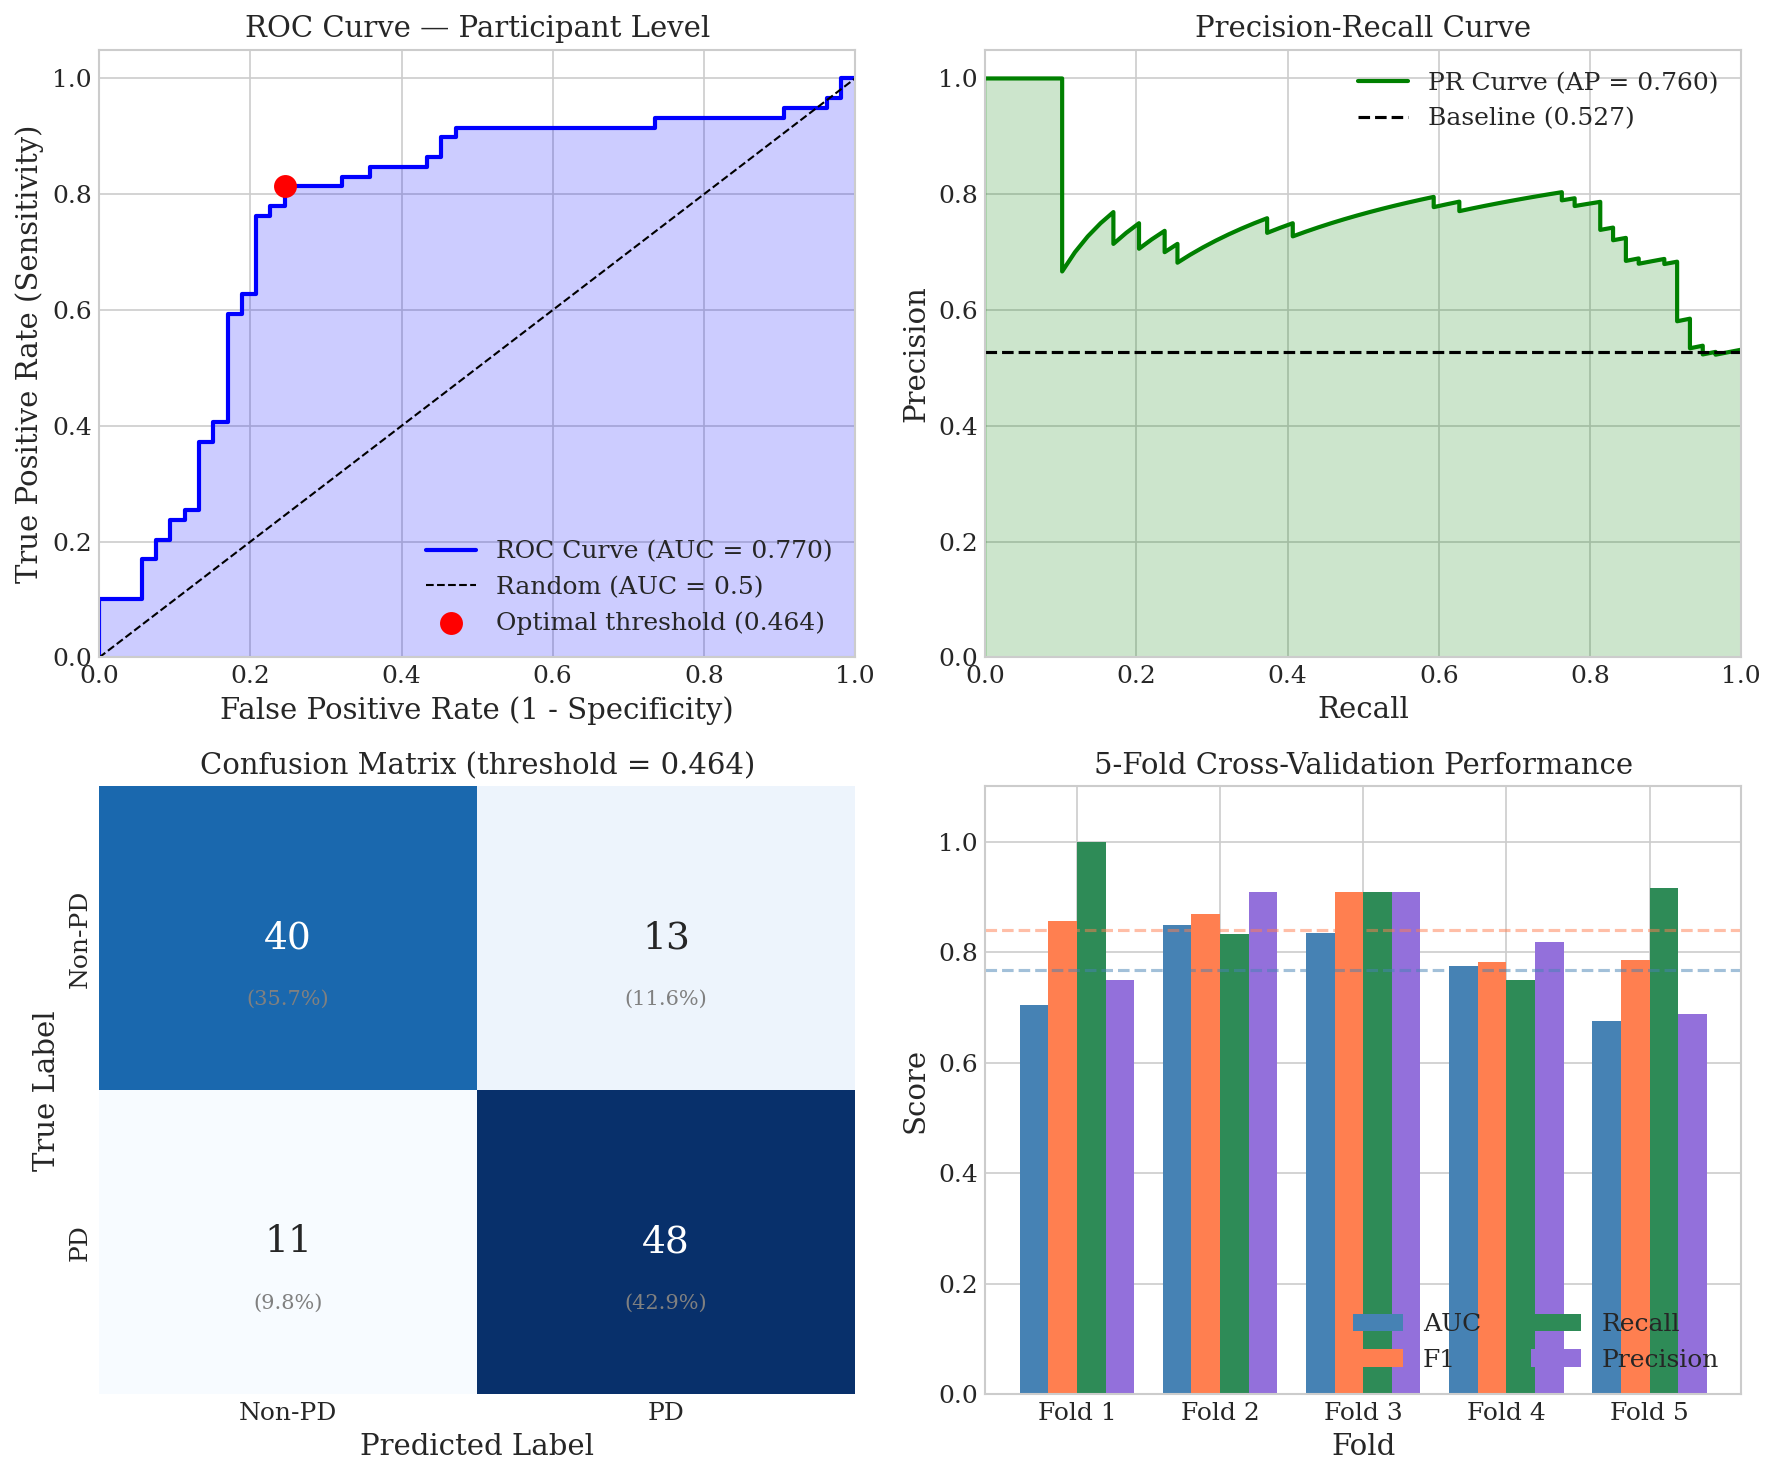


 Saved: pd_classification_results.png
 Saved: pd_classification_results.pdf


In [15]:
#13 — Final Results & Visualizations
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, f1_score, recall_score, 
    precision_score, roc_auc_score
)


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'figure.dpi': 150,
    'font.family': 'serif'
})

# Calculate OOF metrics

# ROC curve
fpr, tpr, thresholds = roc_curve(all_oof_labels, all_oof_probs)
roc_auc = auc(fpr, tpr)

# Optimal threshold (Youden's J)
opt_idx = np.argmax(tpr - fpr)
opt_threshold = thresholds[opt_idx]

# Predictions at optimal threshold
oof_preds_opt = (all_oof_probs >= opt_threshold).astype(int)

# Precision-Recall curve
precision_curve, recall_curve, _ = precision_recall_curve(all_oof_labels, all_oof_probs)
avg_precision = average_precision_score(all_oof_labels, all_oof_probs)

# Confusion matrix
cm = confusion_matrix(all_oof_labels, oof_preds_opt)

# Create Figure with 4 subplots

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# --- 1. ROC Curve ---
ax1 = axes[0, 0]
ax1.plot(fpr, tpr, 'b-', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax1.scatter(fpr[opt_idx], tpr[opt_idx], c='red', s=100, zorder=5, 
            label=f'Optimal threshold ({opt_threshold:.3f})')
ax1.fill_between(fpr, 0, tpr, alpha=0.2, color='blue')
ax1.set_xlabel('False Positive Rate (1 - Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve — Participant Level')
ax1.legend(loc='lower right')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# --- 2. Precision-Recall Curve ---
ax2 = axes[0, 1]
ax2.plot(recall_curve, precision_curve, 'g-', lw=2, label=f'PR Curve (AP = {avg_precision:.3f})')
ax2.axhline(y=all_oof_labels.mean(), color='k', linestyle='--', 
            label=f'Baseline ({all_oof_labels.mean():.3f})')
ax2.fill_between(recall_curve, 0, precision_curve, alpha=0.2, color='green')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc='upper right')
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])

# --- 3. Confusion Matrix ---
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Non-PD', 'PD'], yticklabels=['Non-PD', 'PD'],
            annot_kws={'size': 18}, cbar=False)
ax3.set_xlabel('Predicted Label')
ax3.set_ylabel('True Label')
ax3.set_title(f'Confusion Matrix (threshold = {opt_threshold:.3f})')

# Add percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        pct = cm[i, j] / total * 100
        ax3.text(j + 0.5, i + 0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=10, color='gray')

# --- 4. Cross-Validation Performance by Fold ---
ax4 = axes[1, 1]

fold_nums = [r['fold'] for r in fold_results]
aucs = [r['auc'] for r in fold_results]
f1s = [r['f1_opt'] for r in fold_results]
recalls = [r['recall_opt'] for r in fold_results]
precisions = [r['precision_opt'] for r in fold_results]

x = np.arange(len(fold_nums))
width = 0.2

bars1 = ax4.bar(x - 1.5*width, aucs, width, label='AUC', color='steelblue')
bars2 = ax4.bar(x - 0.5*width, f1s, width, label='F1', color='coral')
bars3 = ax4.bar(x + 0.5*width, recalls, width, label='Recall', color='seagreen')
bars4 = ax4.bar(x + 1.5*width, precisions, width, label='Precision', color='mediumpurple')

ax4.axhline(y=np.mean(aucs), color='steelblue', linestyle='--', alpha=0.5)
ax4.axhline(y=np.mean(f1s), color='coral', linestyle='--', alpha=0.5)

ax4.set_xlabel('Fold')
ax4.set_ylabel('Score')
ax4.set_title('5-Fold Cross-Validation Performance')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Fold {i}' for i in fold_nums])
ax4.legend(loc='lower right', ncol=2)
ax4.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('pd_classification_results.png', dpi=300, bbox_inches='tight')
plt.savefig('pd_classification_results.pdf', bbox_inches='tight')  # Vector format for paper
plt.show()

print("\n Saved: pd_classification_results.png")
print(" Saved: pd_classification_results.pdf")

In [17]:
#14 — Statistical Analysis & Performance Summary Table
import numpy as np
from scipy import stats

print("="*75)
print("STATISTICAL ANALYSIS & PERFORMANCE SUMMARY")
print("="*75)

# Calculate 95% Confidence Intervals

def calculate_ci(data, confidence=0.95):
    """Calculate mean and 95% CI."""
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    se = std / np.sqrt(n)
    
    # t-distribution for small samples
    t_val = stats.t.ppf((1 + confidence) / 2, n - 1)
    ci_lower = mean - t_val * se
    ci_upper = mean + t_val * se
    
    return mean, std, ci_lower, ci_upper

# Extract metrics from fold results
aucs = [r['auc'] for r in fold_results]
f1s = [r['f1_opt'] for r in fold_results]
recalls = [r['recall_opt'] for r in fold_results]
precisions = [r['precision_opt'] for r in fold_results]

# Calculate statistics
metrics = {
    'AUC-ROC': aucs,
    'F1 Score': f1s,
    'Recall (Sensitivity)': recalls,
    'Precision (PPV)': precisions
}

print("\n### Table 1: 5-Fold Cross-Validation Results (Participant-Level)")
print("-"*75)
print(f"{'Metric':<25} {'Mean':<10} {'Std':<10} {'95% CI':<20}")
print("-"*75)

results_for_paper = {}
for metric_name, values in metrics.items():
    mean, std, ci_low, ci_high = calculate_ci(values)
    results_for_paper[metric_name] = {
        'mean': mean, 'std': std, 'ci_low': ci_low, 'ci_high': ci_high
    }
    print(f"{metric_name:<25} {mean:<10.4f} {std:<10.4f} [{ci_low:.4f}, {ci_high:.4f}]")

print("-"*75)

# OOF (Out-of-Fold) Results — True CV Performance

print("\n### Out-of-Fold (OOF) Aggregated Results")
print("-"*75)

oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)
oof_f1 = f1_score(all_oof_labels, oof_preds_opt)
oof_recall = recall_score(all_oof_labels, oof_preds_opt)
oof_precision = precision_score(all_oof_labels, oof_preds_opt)
oof_specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])  # TN / (TN + FP)

print(f"AUC-ROC:              {oof_auc:.4f}")
print(f"F1 Score:             {oof_f1:.4f}")
print(f"Recall (Sensitivity): {oof_recall:.4f}")
print(f"Precision (PPV):      {oof_precision:.4f}")
print(f"Specificity:          {oof_specificity:.4f}")
print(f"Optimal Threshold:    {opt_threshold:.4f}")
print("-"*75)


# Confusion Matrix Details

print("\n### Confusion Matrix Breakdown")
print("-"*75)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN):  {tn} ({tn/cm.sum()*100:.1f}%)")
print(f"False Positives (FP): {fp} ({fp/cm.sum()*100:.1f}%)")
print(f"False Negatives (FN): {fn} ({fn/cm.sum()*100:.1f}%)")
print(f"True Positives (TP):  {tp} ({tp/cm.sum()*100:.1f}%)")
print("-"*75)

# Classification Report

print("\n### Classification Report")
print("-"*75)
print(classification_report(all_oof_labels, oof_preds_opt, 
                            target_names=['Non-PD', 'PD'], digits=4))



STATISTICAL ANALYSIS & PERFORMANCE SUMMARY

### Table 1: 5-Fold Cross-Validation Results (Participant-Level)
---------------------------------------------------------------------------
Metric                    Mean       Std        95% CI              
---------------------------------------------------------------------------
AUC-ROC                   0.7675     0.0769     [0.6721, 0.8630]
F1 Score                  0.8408     0.0552     [0.7723, 0.9093]
Recall (Sensitivity)      0.8818     0.0944     [0.7646, 0.9990]
Precision (PPV)           0.8148     0.0977     [0.6934, 0.9361]
---------------------------------------------------------------------------

### Out-of-Fold (OOF) Aggregated Results
---------------------------------------------------------------------------
AUC-ROC:              0.7697
F1 Score:             0.8000
Recall (Sensitivity): 0.8136
Precision (PPV):      0.7869
Specificity:          0.7547
Optimal Threshold:    0.4639
------------------------------------------